# Adaptive Generation

TO-DO:
- Run JADES team data through EAZY
- Recover this result: https://arxiv.org/pdf/2601.15960
- Recover Hainline's catalogue: https://iopscience.iop.org/article/10.3847/1538-4357/ad1ee4/pdf

For reference: https://kevinhainline.github.io/eazypy_guide/

In [2]:
# --- Step 1: Load MSAEXP emission line catalog ---
from grizli import utils
from astropy.utils.data import download_file

version = "v4.4" # Updated September 5, 2025.  Include all public spectra even without redshift / line fits

CACHE_DOWNLOADS = True
URL_PREFIX = "https://zenodo.org/records/15472354/files/"

# --- Load MSAEXP emission line catalog ---
table_url = f"{URL_PREFIX}/dja_msaexp_emission_lines_{version}.csv.gz"
spectra = utils.read_catalog(download_file(table_url, cache=CACHE_DOWNLOADS), format='csv')

In [3]:
from astropy.table import Table
from astropy.io import fits

with fits.open('../hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits') as hdul:
    # Read the FILTERS table
    phot_s = Table(hdul['CIRC'].data)

with fits.open('../hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits') as hdul:
    phot_n = Table(hdul['CIRC'].data)

with fits.open('../JADES_DR5_z_gt_8_Catalog_Hainline.fits') as hdul:
    candidates = Table(hdul[1].data)

In [4]:
# --- Step 3: Cross-match photometric and spectroscopic catalogs ---
from scipy.spatial import cKDTree
import numpy as np

# Convert RA,Dec to 3D unit vectors
def radec_to_xyz(ra_deg, dec_deg):
    ra = np.radians(ra_deg)
    dec = np.radians(dec_deg)
    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)
    return np.vstack([x, y, z]).T

# Match photometric and spectroscopic catalogs using KDTree
def match_phot_spec(phot, spectra, rmax=1):
    """Match photometric and spectroscopic catalogs using KDTree.

    Parameters
    ----------
    phot : astropy Table
        Photometric catalog with 'ra' and 'dec' columns.
    spectra : astropy Table
        Spectroscopic catalog with 'ra', 'dec', and 'z_best' columns.
    rmax : float
        Maximum matching radius in arcseconds.

    Returns
    -------
    z_spec : np.ndarray
        Array of spectroscopic redshifts matched to photometric catalog.
        Unmatched entries are set to -1.
    """
    xyz_phot = radec_to_xyz(phot['RA'], phot['DEC'])
    xyz_spec = radec_to_xyz(spectra['ra'], spectra['dec'])

    # Build KDTree of spectroscopic positions
    tree = cKDTree(xyz_spec)

    # Query nearest neighbor
    dist, idx = tree.query(xyz_phot, k=1)

    # dist is chord distance; convert to angular distance
    ang_dist_rad = 2 * np.arcsin(np.clip(dist/2, -1, 1))
    ang_dist_arcsec = np.degrees(ang_dist_rad) * 3600

    # Apply match threshold
    mask = ang_dist_arcsec < rmax

    # Build z_spec array
    z_spec = np.full(len(phot), -1.0)
    z_spec[mask] = spectra['z_best'][idx][mask]

    return z_spec

phot_s['z_spec'] = match_phot_spec(phot_s, spectra, rmax=0.1)
phot_n['z_spec'] = match_phot_spec(phot_n, spectra, rmax=0.1)
candidates['z_spec'] = match_phot_spec(candidates, spectra, rmax=0.1)

In [5]:
# --- Step 4: Get useful data out of photometric catalog ---
import numpy as np
from astropy.table import join

# Extract useful data columns and clean photometry
def extract_and_clean(phot, non_phot, flux_pattern, err_pattern, flag_pattern=None, use_flag=False):
    print("Initial table size:", len(phot))

    # Recommended EAZY missing-data values
    BAD_FLUX = -99.0
    BAD_ERR  = 1e10

    # Grab relevant flux and error columns via pattern matching
    flux_cols = sorted([c for c in phot.colnames if c.endswith(flux_pattern)])
    err_cols  = sorted([c for c in phot.colnames if c.endswith(err_pattern)])
    
    # Verify we have matching pairs
    if len(flux_cols) != len(err_cols):
        raise ValueError(f"Mismatch: Found {len(flux_cols)} fluxes and {len(err_cols)} errors.")

    # Explicitly create a shallow copy of the columns we care about to prevent mutating the input table
    keep_cols = list(non_phot) + flux_cols + err_cols
    if use_flag and flag_pattern:
        flag_cols = sorted([c for c in phot.colnames if flag_pattern in c])
        # Ensure flag count matches flux count
        if len(flag_cols) == len(flux_cols):
            keep_cols += flag_cols
        else:
            print("Warning: Flag column count doesn't match flux columns. Disabling flag masking.")
            use_flag = False

    # Create a fresh working table with only the necessary columns
    working_tab = phot[keep_cols].copy()

    # Initialize boolean mask: all False (len of table)
    has_data = np.zeros(len(working_tab), dtype=bool)

    # If flags are used, match them to fluxes; otherwise iterate flux/error pairs
    zip_iterable = zip(flux_cols, err_cols, flag_cols) if use_flag else zip(flux_cols, err_cols, [None]*len(flux_cols))

    for fcol, ecol, flagcol in zip_iterable:
        # 1. Identify inherently bad elements (NaNs or Infs)
        bad_mask = np.isnan(working_tab[fcol]) | np.isnan(working_tab[ecol]) | np.isinf(working_tab[fcol]) | np.isinf(working_tab[ecol])

        # 2. Add flag criteria if applicable
        if use_flag and flagcol is not None:
            bad_mask |= (working_tab[flagcol] != 0)

        # 3. Apply EAZY specific bad-data values safely
        working_tab[fcol][bad_mask] = BAD_FLUX
        working_tab[ecol][bad_mask] = BAD_ERR

        # 4. Accumulate rows that possess at least one valid band
        # A band is valid if it escaped the bad_mask AND wasn't pre-existing bad data
        valid_band = (~bad_mask) & (working_tab[fcol] != BAD_FLUX) & (working_tab[ecol] != BAD_ERR)
        has_data |= valid_band

    # Slice the table by valid rows and drop the working flag columns to keep it clean
    final_cols = list(non_phot) + flux_cols + err_cols
    tab3 = working_tab[final_cols][has_data]
    
    print("Finished! Final table size:", len(tab3))
    return tab3

In [6]:
# Revised step 4 for JADES data
keep = ["ID", "RA", "DEC", "z_spec"] # columns to keep
# pattern = r"_CIRC0" # regex pattern to match photometry columns
flux_pattern = "1"
err_pattern = "1_e"

cleaned_phot_s = extract_and_clean(phot_s, keep, flux_pattern, err_pattern, use_flag=False)
cleaned_phot_n = extract_and_clean(phot_n, keep, flux_pattern, err_pattern, use_flag=False)
cleaned_candidates = extract_and_clean(candidates, keep, "_flux_nJy", "_flux_err_nJy", use_flag=False)

Initial table size: 304366
Finished! Final table size: 304366
Initial table size: 181144
Finished! Final table size: 181143
Initial table size: 2081
Finished! Final table size: 2081


In [7]:
# Full list of JWST NIRCam + NIRISS + HST ACS + WFC3/UVIS filters
# NOTE - due to filter name overlap, NIRISS and WFC3 are not currently usable.

nircam_filters = ['f150w2', 'f322w2', 
                 'f070w', 'f090w', 'f115w', 'f150w', 'f200w', 'f277w', 'f356w', 'f444w',
                 'f140m', 'f162m', 'f182m', 'f210m', 'f250m', 'f300m', 'f335m', 'f360m', 'f410m', 'f430m', 'f460m', 'f480m',
                 'f164n', 'f187n', 'f212n', 'f323n', 'f405n', 'f466n', 'f470n']
# niriss_filters = ['f090w', 'f115w', 'f150w', 'f200w', 'f277w', 'f356w', 'f444w',
#                   'f140m', 'f158m', 'f380m', 'f430m', 'f480m']
acs_filters = ['f435w', 'f475w', 'f555w', 'f606w', 'f625w', 'f775w', 'f814w', 'f850lp']
# wfc3_ir_filters = ['f105w', 'f110w', 'f125w', 'f140w', 'f160w',
#                    'f098m', 'f127m', 'f139m', 'f153m', 
#                    'f126n', 'f128n', 'f130n', 'f132n', 'f164n', 'f167n']
# wfc3_uvis_filters = ['f218w', 'f225w', 'f275w', 'f336w', 'f390w', 'f438w','f475w', 'f555w', 'f606w', 'f625w', 'f775w', 'f814w',
#                      'f390m', 'f410m', 'f467m', 'f547m', 'f621m', 'f689m', 'f763m', 'f845m',
#                      'f280n', 'f343n', 'f373n', 'f359n', 'f469n', 'f487n', 'f502n', 'f631n', 'f645n', 'f656n', 'f657n', 'f658n', 'f665n', 'f673n', 'f680n', 'f953n',
#                      'fq378n', 'fq387n', 'fq437n', 'fq492n', 'fq508n', 'fq619n', 'fq674n', 'fq750n', 'fq889n', 'fq937n',
#                      'f300x', 'f475x',
#                      'f200lp', 'f350lp', 'f600lp', 'f850lp']
# clearp or wn -> NIRISS
# u -> WFC3/UVIS
# else match NIRCam & ACS

# 105w, 110w, 125w, 140w, 160w are actually WFC3/IR filters
def classify_filter(name):
    """
    Returns (instrument, canonical_filter_name) or ("unknown", name)
    according to your DAWN mapping rules.
    """
    f = name.lower()

    # Just match filter names to instruments (NIRISS and WFC3/UVIS are unusable without more specific pattern info)
    for flt in acs_filters:
        if flt.lower() in f:
            return ("acs", flt)
        
    for flt in nircam_filters:
        if flt.lower() in f:
            return ("nircam", flt)

    # --- Nothing matched
    return ("unknown", name)

In [8]:
import re
import numpy as np

def extract_clean_and_classify(phot, non_phot, flux_pattern, err_pattern, flag_pattern=None, 
                               use_flag=False, use_nircam=True, use_niriss=True, use_wfc3=True, use_acs=True, drop_hst_ir=False):
    """
    Parses, classifies, and cleans catalog data for EAZY in a single unified pass.
    
    column_regex: Raw string regex with two capture groups: (band/filter) and (flux/err type).
                  Example: r'^(CIRC_0\.3)_(f\d{3}[w|m|n])_(flux|fluxerr)$'
    """
    # EAZY-recommended missing data values
    BAD_FLUX = -99.0
    BAD_ERR  = 1e10

    # Compile all three regex patterns
    flux_rx = re.compile(flux_pattern, re.IGNORECASE)
    err_rx  = re.compile(err_pattern, re.IGNORECASE)
    flag_rx = re.compile(flag_pattern, re.IGNORECASE) if (use_flag and flag_pattern) else None
    
    # Storage maps for column names indexed by filter string
    flux_map = {}
    err_map  = {}
    flag_map = {}
    
    # 1. Scan all columns once to catalog everything by filter name
    for col in phot.colnames:
        f_match = flux_rx.match(col)
        if f_match:
            fname = f_match.group('filter').lower()
            flux_map[fname] = col
            continue
            
        e_match = err_rx.match(col)
        if e_match:
            fname = e_match.group('filter').lower()
            err_map[fname] = col
            continue
            
        if flag_rx:
            flg_match = flag_rx.match(col)
            if flg_match:
                fname = flg_match.group('filter').lower()
                flag_map[fname] = col

    # 2. Match up triplets/pairs and classify
    valid_flux_cols = []
    valid_err_cols  = []
    valid_flag_cols = []
    instrument_cat  = []
    filter_cat      = []

    for fname, fcol in flux_map.items():
        # Core requirement: Must have a matching error column
        if fname not in err_map:
            print(f"Warning: Found flux for {fname} ({fcol}) but no matching error column. Skipping.")
            continue
            
        ecol = err_map[fname]
        
        # Check for flags if flag processing is activated
        if use_flag and flag_rx:
            if fname in flag_map:
                valid_flag_cols.append(flag_map[fname])
            else:
                print(f"Note: Flags enabled, but found no flag column for band {fname}. Proceeding without flag filtering for this band.")
                valid_flag_cols.append(None)
        else:
            valid_flag_cols.append(None)

        # Classify the filter using your underlying setup rules
        inst, canonical_flt = classify_filter(fname)
        
        # Check configuration switches
        if inst == "unknown":
            print(f"Unknown instrument/filter configuration for: {fname}")
            continue
        elif inst == "nircam" and not use_nircam: continue
        elif inst == "niriss" and not use_niriss: continue
        elif inst == "wfc3-uvis" and not use_wfc3: continue
        elif inst == "acs" and not use_acs: continue
        elif inst == "wfc3-ir":
            if not use_wfc3 or drop_hst_ir: 
                continue
        
        valid_flux_cols.append(fcol)
        valid_err_cols.append(ecol)
        instrument_cat.append(inst)
        filter_cat.append(canonical_flt)

    # 3. Third Pass: Perform Vectorized Extraction and Missing-Data Cleaning
    keep_cols = list(non_phot) + valid_flux_cols + valid_err_cols
    # Merge active flag column strings into slicing list
    keep_cols += [f for f in valid_flag_cols if f is not None]
    
    working_tab = phot[keep_cols].copy()
    has_data = np.zeros(len(working_tab), dtype=bool)

    for fcol, ecol, flagcol in zip(valid_flux_cols, valid_err_cols, valid_flag_cols):
        # Build vectorized boolean masks
        bad_mask = np.isnan(working_tab[fcol]) | np.isnan(working_tab[ecol]) | \
                   np.isinf(working_tab[fcol]) | np.isinf(working_tab[ecol])

        if use_flag and flagcol is not None:
            bad_mask |= (working_tab[flagcol] != 0)

        # Vectorized assignment
        working_tab[fcol][bad_mask] = BAD_FLUX
        working_tab[ecol][bad_mask] = BAD_ERR

        # Track rows containing actual information
        valid_band = (~bad_mask) & (working_tab[fcol] != BAD_FLUX) & (working_tab[ecol] != BAD_ERR)
        has_data |= valid_band

    # Cut table to final rows/columns
    final_cols = list(non_phot) + valid_flux_cols + valid_err_cols
    tab_final = working_tab[final_cols][has_data]
    
    print("Finished! Final table size:", len(tab_final))
    
    return instrument_cat, filter_cat, tab_final, valid_flux_cols, valid_err_cols

In [9]:
# Define regex patterns for flux and error columns then perform full extraction, cleaning, and classification in one step
flux_pattern = r"^(?P<filter>F\d+[A-Z]*)_CIRC1$"
err_pattern  = r"^(?P<filter>F\d+[A-Z]*)_CIRC1_e$"

instrument_cat_s, filter_cat_s, tab_final_s, s_fluxes, s_errs = extract_clean_and_classify(phot_s, keep, flux_pattern, err_pattern, flag_pattern=None, use_flag=False)
instrument_cat_n, filter_cat_n, tab_final_n, n_fluxes, n_errs = extract_clean_and_classify(phot_n, keep, flux_pattern, err_pattern, flag_pattern=None, use_flag=False)
instrument_cat_c, filter_cat_c, tab_final_c, c_fluxes, c_errs = extract_clean_and_classify(candidates, keep, r"^(?P<filter>F\d+[A-Z]*)_flux_nJy$", r"^(?P<filter>F\d+[A-Z]*)_flux_err_nJy$", flag_pattern=None, use_flag=False)

Unknown instrument/filter configuration for: f105w
Unknown instrument/filter configuration for: f125w
Unknown instrument/filter configuration for: f140w
Unknown instrument/filter configuration for: f160w
Finished! Final table size: 304366
Unknown instrument/filter configuration for: f105w
Unknown instrument/filter configuration for: f125w
Unknown instrument/filter configuration for: f140w
Unknown instrument/filter configuration for: f160w
Finished! Final table size: 181142
Finished! Final table size: 2081


In [10]:
# Trim all objects with SNR < 5 in 2 or more of the Hainline bands
def snr_trim(tab_final, bands, flux_pattern, err_pattern):
    """
    Performs an SNR cut requiring objects to be detected at SNR > 5 
    in at least 2 of the user-specified bands.
    
    bands: List of string names to enforce the cut on (e.g., ['f115w', 'f150w', 'f200w'])
    flux_pattern / err_pattern: The exact regex strings used during your extraction phase.
    """
    # Compile the regex strings
    flux_rx = re.compile(flux_pattern, re.IGNORECASE)
    err_rx  = re.compile(err_pattern, re.IGNORECASE)
    
    # 1. Map column names to their underlying filter string
    # e.g., {'f115w': 'HST_F115W_flux'}
    flux_map = {}
    err_map  = {}
    
    for col in tab_final.colnames:
        f_match = flux_rx.match(col)
        if f_match:
            fname = f_match.group('filter').lower()
            flux_map[fname] = col
            continue
            
        e_match = err_rx.match(col)
        if e_match:
            fname = e_match.group('filter').lower()
            err_map[fname] = col

    # 2. Build our SNR check array only for the requested bands that exist in the table
    snr_vectors = []
    active_bands = [b.lower() for b in bands]
    
    for b in active_bands:
        if b in flux_map and b in err_map:
            fcol = flux_map[b]
            ecol = err_map[b]
            
            # Calculate the SNR vector for this specific band
            band_snr = np.array(tab_final[fcol] / tab_final[ecol])
            snr_vectors.append(band_snr)
        else:
            print(f"Note: Band '{b}' requested for SNR trimming was not found in the catalog columns. Skipping.")

    if not snr_vectors:
        print("Warning: No matching bands found for SNR trimming. Returning original table unmodified.")
        return tab_final

    # Stack into a 2D array: (n_objects, n_matched_bands)
    snr = np.vstack(snr_vectors).T

    # 3. Evaluate detection criteria
    # Identify entries that are both finite and above the 5-sigma detection limit
    valid_snr = (snr > 5) & np.isfinite(snr)
    
    # Count how many of the specified bands meet the criteria for each row
    count = np.sum(valid_snr, axis=1)

    # Hainline criterion: Must be detected in at least 2 bands
    good = count >= 2

    clean_phot = tab_final[good]
    print(f"{len(tab_final) - len(clean_phot)} objects removed by SNR cut. Remaining: {len(clean_phot)}")

    return clean_phot

In [11]:
bands_s = ['F150W', 'F200W', 'F277W', 'F335M', 'F356W', 'F410M', 'F444W']
bands_n = ['F150W', 'F200W', 'F277W', 'F335M', 'F356W', 'F410M', 'F444W']
flux_pattern = r"^(?P<filter>F\d+[A-Z]*)_CIRC1$"
err_pattern  = r"^(?P<filter>F\d+[A-Z]*)_CIRC1_e$"

clip_1_s = snr_trim(tab_final_s, bands_s, flux_pattern, err_pattern)
clip_1_n = snr_trim(tab_final_n, bands_n, flux_pattern, err_pattern)

76594 objects removed by SNR cut. Remaining: 227772
56517 objects removed by SNR cut. Remaining: 124625


In [12]:
# Delete objects with 10x brighter neighbors within 0.3"
from astropy.coordinates import SkyCoord
import astropy.units as u

def filter_nearest_neighbors(clean_phot, bands, flux_pattern):
    """
    Remove objects that have a neighbor within 0.3" that is >10x brighter in any band.
    
    bands: List of string names to enforce the cut on (e.g., ['f115w', 'f150w'])
    flux_pattern: The exact regex string used during your extraction phase.
    """
    # 1. Coordinate matching remains the same
    coords = SkyCoord(ra=clean_phot['RA']*u.deg, dec=clean_phot['DEC']*u.deg)
    idx1, idx2, sep2d, _ = coords.search_around_sky(coords, 0.3*u.arcsec)
    
    # Avoid self-matches and double-counting pairs
    mask = idx1 < idx2
    idx1 = idx1[mask]
    idx2 = idx2[mask]

    print(f"Found {len(idx1)} pairs within 0.3\". Applying neighbor flux ratio cut...")

    # 2. Map column names to their underlying filter string using regex
    flux_rx = re.compile(flux_pattern, re.IGNORECASE)
    flux_map = {}
    
    for col in clean_phot.colnames:
        f_match = flux_rx.match(col)
        if f_match:
            fname = f_match.group('filter').lower()
            flux_map[fname] = col

    # 3. Build our flux comparison array only for the requested bands that exist
    flux_vectors = []
    active_bands = [b.lower() for b in bands]
    
    for b in active_bands:
        if b in flux_map:
            fcol = flux_map[b]
            flux_vectors.append(np.array(clean_phot[fcol]))
        else:
            print(f"Note: Band '{b}' requested for neighbor check was not found in catalog columns. Skipping.")

    if not flux_vectors:
        print("Warning: No matching bands found for neighbor flux cuts. Returning original table unmodified.")
        return clean_phot

    # Stack into a 2D array: (n_objects, n_matched_bands)
    flux = np.vstack(flux_vectors).T

    # 4. Perform the ratio evaluation logic
    f1 = flux[idx1]
    f2 = flux[idx2]

    # Mask out bad or non-physical data (zero/negative fluxes confuse division ratios)
    valid = (~np.isnan(f1)) & (~np.isnan(f2)) & (f1 > 0) & (f2 > 0)

    ratio = f1 / f2
    ratio_inv = f2 / f1

    ten_x_1 = (ratio > 10) & valid     # obj1 is >10x brighter than obj2
    ten_x_2 = (ratio_inv > 10) & valid # obj2 is >10x brighter than obj1

    print(f"{ten_x_1.sum()} instances where object 1 is >10x brighter.")
    print(f"{ten_x_2.sum()} instances where object 2 is >10x brighter.")

    # Track indexes slated for deletion
    delete = np.zeros(len(clean_phot), dtype=bool)

    # If obj1 is brighter -> delete obj2
    delete[idx2[np.any(ten_x_1, axis=1)]] = True

    # If obj2 is brighter -> delete obj1
    delete[idx1[np.any(ten_x_2, axis=1)]] = True

    sec_cut_phot = clean_phot[~delete]
    print(f"{delete.sum()} objects removed by neighbor flux ratio cut. Remaining: {len(sec_cut_phot)}")

    return sec_cut_phot

In [13]:
# filtered_s = filter_nearest_neighbors(clip_1_s, bands_s, flux_pattern)
# filtered_n = filter_nearest_neighbors(clip_1_n, bands_n, flux_pattern)

# New Hainline paper doesn't do this step
filtered_s = clip_1_s
filtered_n = clip_1_n

# Writeout

In [14]:
# -- Step 8: Write zphot.translate & full catalogue ---
# This currently includes all NIRCam and ACS filters
translate = {
  'f070w': 362,
  'f090w': 363,
  'f115w': 364,
  'f150w': 365,
  'f200w': 366,
  'f150w2': 367,
  'f140m': 368,
  'f162m': 369,
  'f182m': 370,
  'f210m': 371,
  'f164n': 372,
  'f187n': 373,
  'f212n': 374,
  'f277w': 375,
  'f356w': 376,
  'f444w': 377,
  'f250m': 379,
  'f300m': 380,
  'f335m': 381,
  'f360m': 382,
  'f410m': 383,
  'f430m': 384,
  'f460m': 385,
  'f480m': 386,
  'f323n': 387,
  'f405n': 388,
  'f466n': 389,
  'f470n': 390,
  'f435w': 233,
  'f475w': 234,
  'f555w': 235,
  'f606w': 236,
  'f625w': 237,
  'f775w': 238,
  'f814w': 239,
  'f850lp': 240
}

def write_photometry(result, instrument_cat, filter_cat, flux_cols, err_cols, 
                     translate_dict, name, only_spec=False, only_highz=False):
    """
    Writes a standard EAZY-compliant template .cat catalog.
    
    flux_cols / err_cols: Ordered lists of explicit string column names derived from your extraction step.
    translate_dict: Dictionary mapping the lower-case filter base name to its EAZY FILTER.RES id number.
                    e.g., {'f090w': 204, 'f115w': 205}
    """
    if only_highz:
        tab_final = result[result['z_spec'] > 8]
    elif only_spec:
        tab_final = result[result['z_spec'] != -1]
    else:
        tab_final = result

    n_obj = len(tab_final)
    if n_obj == 0:
        print(f"Warning: No sources matched criteria for {name}.cat. Skipping export.")
        return None

    # 2. Build Headers dynamically using the translate dictionary numbers
    # Pretty header for human sanity checks
    pretty_elements = ["id"]
    for instr, filt in zip(instrument_cat, filter_cat):
        pretty_elements.extend([f"f_{instr}_{filt}", f"e_{instr}_{filt}"])
    pretty_elements.append("z_spec")
    pretty_header = "# " + " ".join(pretty_elements)

    # Machine header formatted specifically for EAZY's translated column tracker
    machine_elements = ["id"]
    for filt in filter_cat:
        filt_key = filt.lower()
        if filt_key in translate_dict:
            res_id = translate_dict[filt_key]
        else:
            raise KeyError(f"Filter '{filt}' not found in translate dictionary. Update your mapping keys.")
        machine_elements.extend([f"F{res_id}", f"E{res_id}"])
    machine_elements.append("z_spec")
    machine_header = "# " + " ".join(machine_elements)

    # 3. Streamlined File Writing Using Generator Expressions (Highly Memory Efficient)
    output_path = f"../inputs/{name}.cat"
    
    with open(output_path, "w", encoding="ascii") as fp:
        fp.write(pretty_header + "\n")
        fp.write(machine_header + "\n")

        # Zip array data directly down the rows without translating the entire dataset 
        # into huge nested string lists inside your RAM first.
        columns_to_zip = [tab_final['ID']]
        for fcol, ecol in zip(flux_cols, err_cols):
            columns_to_zip.extend([tab_final[fcol], tab_final[ecol]])
        columns_to_zip.append(tab_final['z_spec'])

        # Write data rows
        for row in zip(*columns_to_zip):
            # row[0] is ID (int), row[-1] is z_spec (float), everything else is flux/error (float)
            line = f"{int(row[0]):6d} " + " ".join(f"{x:.6e}" for x in row[1:-1]) + f" {row[-1]:.4f}\n"
            fp.write(line)

    print(f"Wrote {output_path} with {n_obj} objects and {len(filter_cat)} filters.")
    return None

# Cycle through 10K at a time to avoid memory issues
def split_photometry(result, instrument_cat, filter_cat, flux_cols, err_cols, translate_dict, name, only_spec=False, only_highz=False):
    for segment in range(len(result)//10000 + 1):
        segment_tab = result[segment*10000:(segment+1)*10000]
        write_photometry(segment_tab, instrument_cat, filter_cat, flux_cols, err_cols, translate_dict, name + f'_{segment}', only_spec=only_spec, only_highz=only_highz)

In [15]:
split_photometry(filtered_s, instrument_cat_s, filter_cat_s, s_fluxes, s_errs, translate, "INPUT/jades_gds-s_full", only_spec=False, only_highz=False)
split_photometry(filtered_n, instrument_cat_n, filter_cat_n, n_fluxes, n_errs, translate, "INPUT/jades_gds-n_full", only_spec=False, only_highz=False)
split_photometry(tab_final_c, instrument_cat_c, filter_cat_c, c_fluxes, c_errs, translate, "INPUT/jades_candidates_full", only_spec=False, only_highz=False)

Wrote ../inputs/INPUT/jades_gds-s_full_0.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_1.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_2.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_3.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_4.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_5.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_6.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_7.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_8.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_9.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_10.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full_11.cat with 10000 objects and 23 filters.
Wrote ../inputs/INPUT/jades_gds-s_full

In [16]:
def write_translation_file(instrument_cat, filter_cat, translate_dict, name):
    """
    Generates an EAZY-compliant .translate file matching the catalog structure.
    
    Format: f_{instrument}_{filter}  {FILTER.RES_ID}
    """
    output_path = f"../inputs/{name}.translate"
    
    # We use a list to collect lines first, then join them—this is faster than 
    # repeated += string operations for larger filter sets.
    translate_lines = []
    
    for inst, filt in zip(instrument_cat, filter_cat):
        filt_key = filt.lower()
        if filt_key in translate_dict:
            res_id = translate_dict[filt_key]
            # Column headers were created as f_{instr}_{filt} and e_{instr}_{filt}
            # The translate file needs to map these to the FILTER.RES indices.
            translate_lines.append(f"f_{inst}_{filt}  F{res_id}")
            translate_lines.append(f"e_{inst}_{filt}  E{res_id}")
        else:
            print(f"Warning: {filt_key} missing from translate_dict. Translation file may be incomplete.")

    with open(output_path, "w", encoding="ascii") as f:
        f.write("\n".join(translate_lines) + "\n")
        
    print(f"Wrote {output_path} with {len(translate_lines)} entries.")

write_translation_file(instrument_cat_s, filter_cat_s, translate, "jades_gds-s_full")
write_translation_file(instrument_cat_n, filter_cat_n, translate, "jades_gds-n_full")
write_translation_file(instrument_cat_c, filter_cat_c, translate, "jades_candidates_full")

Wrote ../inputs/jades_gds-s_full.translate with 46 entries.
Wrote ../inputs/jades_gds-n_full.translate with 42 entries.
Wrote ../inputs/jades_candidates_full.translate with 46 entries.


In [39]:
import eazy
from eazy import photoz
from pathlib import Path

# Path.mkdir("../inputs/OUTPUT", exist_ok=True)

for photo_id in range(1): # CHANGE THIS
    filename = f'../inputs/INPUT/jades_gds-s_full_{photo_id}.cat' # CHANGE THIS

    # 1. Define parameter dictionary
    params = {
        'CATALOG_FILE': filename,
        'MAIN_OUTPUT_FILE': f'../inputs/OUTPUT_S', # CHANGE THIS
        'Z_STEP': 0.01,
        'Z_MIN': 0.01,
        'Z_MAX': 22.0,
        'PRIOR_AB_MAGBIN': 'n',      # Turn off prior
        'TEMPLATES_FILE': '../eazy-py_test/templates.param',
        'FILTERS_RES': '../inputs/FILTER.RES.latest',
        'IGM_IN06_WAVELENGTH': 1216.0,
        'APPLY_IGM': 'y',
        'TEMPL_ERR_FILE': '../templates/TEMPLATE_ERROR.v2.0.zfourge',
        'ERR_FAC': 1.0,
        'SYS_ERR': 0.05,              # Adding a 5% error floor
        'TEMPLATE_COMBOS': 'a',
        'MW_EBV': 0.012,
        # 'TEMP_ERR_A2': 1.00,        # Template error amplitude
        'H0': 70.0,
        'SCALE_2175_BUMP': 0.00,
        'OMEGA_M': 0.3,
        'OMEGA_L': 0.7
    }

    # 2. Create the PhotoZ object
    ez = eazy.photoz.PhotoZ(param_file=None, 
                            translate_file=f'../inputs/jades_gds-s_full.translate', # CHANGE THIS
                            params=params, 
                            zeropoint_file=f'../inputs/jades_hst.zeropoint',
                            load_priors=False,
                            n_processes=6)

    ez.fit_catalog(n_proc=6)

    # Check for final 3 conditions: z_a > 8, pz integral condition, & minima condition

    # Extract z > 8
    zbest = ez.zbest
    # z_cond = zbest > 8
    lnp = ez.lnp
    zgrid = ez.zgrid

    # Check minimum chi2 at z < 7
    chi2 = -2 * lnp # Since we only care about relative
    chi2_min_all = np.min(chi2, axis=1)
    zmask_low = zgrid < 7

    chi2_low = chi2[:, zmask_low]
    chi2_min_low = np.min(chi2_low, axis=1)
    delta_chi2 = chi2_min_low - chi2_min_all

    chi2_cond = delta_chi2 > 4

    # Report final passing candidates
    final_mask = chi2_cond #z_cond & 
    
    # Slice the EAZY catalog down to just the passing rows
    final_candidates = ez.cat

    # Calculate exact boundary markers dynamically
    start_idx = 10000 * photo_id
    end_idx   = start_idx + len(ez.cat) # Automatically handles a shorter final chunk!

    # Slice out the exact coordinate sub-segment
    coord_segment = filtered_s[start_idx:end_idx] # CHANGE THIS

    # Apply the mask safely
    final_candidates['RA']  = coord_segment['RA']
    final_candidates['DEC'] = coord_segment['DEC']
    final_candidates['z_a'] = ez.zbest

    # CHANGE THIS
    final_candidates.write(f'../inputs/OUTPUT_S/S{photo_id}_final_candidates.ecsv', format='ascii.ecsv', overwrite=True)
    np.save(f'../inputs/OUTPUT_S/S{photo_id}_final_mask.ecsv', final_mask)

Read default param file: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/eazy/data/zphot.param.default
Read CATALOG_FILE: ../inputs/INPUT/jades_gds-s_full_0.cat
   >>> NOBJ = 10000
f_nircam_f070w e_nircam_f070w (362): jwst_nircam_f070w
f_nircam_f090w e_nircam_f090w (363): jwst_nircam_f090w
f_nircam_f115w e_nircam_f115w (364): jwst_nircam_f115w
f_nircam_f150w e_nircam_f150w (365): jwst_nircam_f150w
f_nircam_f162m e_nircam_f162m (369): jwst_nircam_f162m
f_nircam_f182m e_nircam_f182m (370): jwst_nircam_f182m
f_nircam_f200w e_nircam_f200w (366): jwst_nircam_f200w
f_nircam_f210m e_nircam_f210m (371): jwst_nircam_f210m
f_nircam_f250m e_nircam_f250m (379): jwst_nircam_f250m
f_nircam_f277w e_nircam_f277w (375): jwst_nircam_f277w
f_nircam_f300m e_nircam_f300m (380): jwst_nircam_f300m
f_nircam_f335m e_nircam_f335m (381): jwst_nircam_f335m
f_nircam_f356w e_nircam_f356w (376): jwst_nircam_f356w
f_nircam_f410m e_nircam_f410m (383): jwst_nircam_f410m
f_nircam_f430m e_

  0%|          | 0/16 [00:00<?, ?it/s]

Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://g

100%|██████████| 16/16 [00:06<00:00,  2.50it/s]


Template   0: eazy_v1.1_sed5.sed (NZ=1).
Template   1: eazy_v1.1_sed4.sed (NZ=1).
Template   2: eazy_v1.1_sed3.sed (NZ=1).
Template   3: eazy_v1.1_sed2.sed (NZ=1).
Template   4: eazy_v1.1_sed1.sed (NZ=1).
Template   5: eazy_v1.1_sed7.sed (NZ=1).
Template   6: erb2010_highEW.sed (NZ=1).
Template   7: c09_del_8.6_z_0.019_chab_age09.40_av2.0.sed (NZ=1).
Template   8: JADES_v1.0_1.sed (NZ=1).
Template   9: JADES_v1.0_2.sed (NZ=1).
Template  10: JADES_v1.0_3.sed (NZ=1).
Template  11: JADES_v1.0_4.sed (NZ=1).
Template  12: JADES_v1.0_5.sed (NZ=1).
Template  13: JADES_v1.0_6.sed (NZ=1).
Template  14: JADES_v1.0_7.sed (NZ=1).
Template  15: eazy_v1.1_sed6.sed (NZ=1).
Process templates: 6.697 s


313it [00:00, 681.59it/s]
  0%|          | 0/313 [00:00<?, ?it/s]

Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git


100%|██████████| 313/313 [01:13<00:00,  4.24it/s]


Compute best fits
fit_best: 1.5 s (n_proc=1,  NOBJ=9967)
Fit 75.7 s (n_proc=6, NOBJ=10000)


In [18]:
import eazy
from eazy import photoz
from pathlib import Path

# Path.mkdir("../inputs/OUTPUT", exist_ok=True)

for photo_id in range(13): # CHANGE THIS
    filename = f'../inputs/INPUT/jades_gds-n_full_{photo_id}.cat' # CHANGE THIS

    # 1. Define parameter dictionary
    params = {
        'CATALOG_FILE': filename,
        'MAIN_OUTPUT_FILE': f'../inputs/OUTPUT_N', # CHANGE THIS
        'Z_STEP': 0.01,
        'Z_MIN': 0.01,
        'Z_MAX': 22.0,
        'PRIOR_AB_MAGBIN': 'n',      # Turn off prior
        'TEMPLATES_FILE': '../eazy-py_test/templates.param',
        'FILTERS_RES': '../inputs/FILTER.RES.latest',
        'IGM_IN06_WAVELENGTH': 1216.0,
        'APPLY_IGM': 'y',
        'TEMPL_ERR_FILE': '../templates/TEMPLATE_ERROR.v2.0.zfourge',
        'ERR_FAC': 1.0,
        'SYS_ERR': 0.05,              # Adding a 5% error floor
        'TEMPLATE_COMBOS': 'a',
        'MW_EBV': 0.012,
        # 'TEMP_ERR_A2': 1.00,        # Template error amplitude
        'H0': 70.0,
        'SCALE_2175_BUMP': 0.00,
        'OMEGA_M': 0.3,
        'OMEGA_L': 0.7
    }

    # 2. Create the PhotoZ object
    ez = eazy.photoz.PhotoZ(param_file=None, 
                            translate_file=f'../inputs/jades_gds-n_full.translate', # CHANGE THIS
                            params=params, 
                            zeropoint_file=f'../inputs/jades_north.zeropoint',
                            load_priors=False,
                            n_processes=6)

    ez.fit_catalog(n_proc=6)

    # Check for final 3 conditions: z_a > 8, pz integral condition, & minima condition

    # Extract z > 8
    zbest = ez.zbest
    # z_cond = zbest > 8
    lnp = ez.lnp
    zgrid = ez.zgrid

    # Check minimum chi2 at z < 7
    chi2 = -2 * lnp # Since we only care about relative
    chi2_min_all = np.min(chi2, axis=1)
    zmask_low = zgrid < 7

    chi2_low = chi2[:, zmask_low]
    chi2_min_low = np.min(chi2_low, axis=1)
    delta_chi2 = chi2_min_low - chi2_min_all

    chi2_cond = delta_chi2 > 4

    # Report final passing candidates
    final_mask = chi2_cond #z_cond & 
    
    # Slice the EAZY catalog down to just the passing rows
    final_candidates = ez.cat

    # Calculate exact boundary markers dynamically
    start_idx = 10000 * photo_id
    end_idx   = start_idx + len(ez.cat) # Automatically handles a shorter final chunk!

    # Slice out the exact coordinate sub-segment
    coord_segment = filtered_n[start_idx:end_idx] # CHANGE THIS

    # Apply the mask safely
    final_candidates['RA']  = coord_segment['RA']
    final_candidates['DEC'] = coord_segment['DEC']
    final_candidates['z_a'] = ez.zbest

    # CHANGE THIS
    final_candidates.write(f'../inputs/OUTPUT_N/N{photo_id}_final_candidates.ecsv', format='ascii.ecsv', overwrite=True)
    np.save(f'../inputs/OUTPUT_N/N{photo_id}_final_mask.ecsv', final_mask)

Read default param file: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/eazy/data/zphot.param.default
Read CATALOG_FILE: ../inputs/INPUT/jades_gds-n_full_0.cat
   >>> NOBJ = 10000
f_nircam_f070w e_nircam_f070w (362): jwst_nircam_f070w
f_nircam_f090w e_nircam_f090w (363): jwst_nircam_f090w
f_nircam_f115w e_nircam_f115w (364): jwst_nircam_f115w
f_nircam_f150w e_nircam_f150w (365): jwst_nircam_f150w
f_nircam_f162m e_nircam_f162m (369): jwst_nircam_f162m
f_nircam_f182m e_nircam_f182m (370): jwst_nircam_f182m
f_nircam_f200w e_nircam_f200w (366): jwst_nircam_f200w
f_nircam_f210m e_nircam_f210m (371): jwst_nircam_f210m
f_nircam_f277w e_nircam_f277w (375): jwst_nircam_f277w
f_nircam_f300m e_nircam_f300m (380): jwst_nircam_f300m
f_nircam_f335m e_nircam_f335m (381): jwst_nircam_f335m
f_nircam_f356w e_nircam_f356w (376): jwst_nircam_f356w
f_nircam_f410m e_nircam_f410m (383): jwst_nircam_f410m
f_nircam_f430m e_nircam_f430m (384): jwst_nircam_f430m
f_acs_f435w e_acs

  0%|          | 0/16 [00:00<?, ?it/s]

Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://g

100%|██████████| 16/16 [00:10<00:00,  1.52it/s]


Template   0: eazy_v1.1_sed5.sed (NZ=1).
Template   1: eazy_v1.1_sed4.sed (NZ=1).
Template   2: eazy_v1.1_sed3.sed (NZ=1).
Template   3: eazy_v1.1_sed2.sed (NZ=1).
Template   4: eazy_v1.1_sed1.sed (NZ=1).
Template   5: eazy_v1.1_sed7.sed (NZ=1).
Template   6: erb2010_highEW.sed (NZ=1).
Template   7: c09_del_8.6_z_0.019_chab_age09.40_av2.0.sed (NZ=1).
Template   8: JADES_v1.0_1.sed (NZ=1).
Template   9: JADES_v1.0_2.sed (NZ=1).
Template  10: JADES_v1.0_3.sed (NZ=1).
Template  11: JADES_v1.0_4.sed (NZ=1).
Template  12: JADES_v1.0_5.sed (NZ=1).
Template  13: JADES_v1.0_6.sed (NZ=1).
Template  14: JADES_v1.0_7.sed (NZ=1).
Template  15: eazy_v1.1_sed6.sed (NZ=1).
Process templates: 10.858 s


...

Template   0: eazy_v1.1_sed5.sed (NZ=1).
Template   1: eazy_v1.1_sed4.sed (NZ=1).
Template   2: eazy_v1.1_sed3.sed (NZ=1).
Template   3: eazy_v1.1_sed2.sed (NZ=1).
Template   4: eazy_v1.1_sed1.sed (NZ=1).
Template   5: eazy_v1.1_sed7.sed (NZ=1).
Template   6: erb2010_highEW.sed (NZ=1).
Template   7: c09_del_8.6_z_0.019_chab_age09.40_av2.0.sed (NZ=1).
Template   8: JADES_v1.0_1.sed (NZ=1).
Template   9: JADES_v1.0_2.sed (NZ=1).
Template  10: JADES_v1.0_3.sed (NZ=1).
Template  11: JADES_v1.0_4.sed (NZ=1).
Template  12: JADES_v1.0_5.sed (NZ=1).
Template  13: JADES_v1.0_6.sed (NZ=1).
Template  14: JADES_v1.0_7.sed (NZ=1).
Template  15: eazy_v1.1_sed6.sed (NZ=1).
Process templates: 6.144 s


313it [00:00, 1737.10it/s]
  0%|          | 0/313 [00:00<?, ?it/s]

Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git


100%|██████████| 313/313 [00:35<00:00,  8.76it/s]


Compute best fits
fit_best: 0.7 s (n_proc=1,  NOBJ=4592)
Fit 36.6 s (n_proc=6, NOBJ=4625)


In [29]:
import eazy
from eazy import photoz
from pathlib import Path

# Path.mkdir("../inputs/OUTPUT", exist_ok=True)

for photo_id in range(1): # CHANGE THIS
    filename = f'../inputs/INPUT/jades_candidates_full_{photo_id}.cat' # CHANGE THIS

    # 1. Define parameter dictionary
    params = {
        'CATALOG_FILE': filename,
        'MAIN_OUTPUT_FILE': f'../inputs/OUTPUT_C', # CHANGE THIS
        'Z_STEP': 0.01,
        'Z_MIN': 0.01,
        'Z_MAX': 22.0,
        'PRIOR_AB_MAGBIN': 'n',      # Turn off prior
        'TEMPLATES_FILE': '../eazy-py_test/templates.param',
        'FILTERS_RES': '../inputs/FILTER.RES.latest',
        'IGM_IN06_WAVELENGTH': 1216.0,
        'APPLY_IGM': 'y',
        'TEMPL_ERR_FILE': '../templates/TEMPLATE_ERROR.v2.0.zfourge',
        'ERR_FAC': 1.0,
        'SYS_ERR': 0.05,              # Adding a 5% error floor
        'TEMPLATE_COMBOS': 'a',
        'MW_EBV': 0.012,
        # 'TEMP_ERR_A2': 1.00,        # Template error amplitude
        'H0': 70.0,
        'SCALE_2175_BUMP': 0.00,
        'OMEGA_M': 0.3,
        'OMEGA_L': 0.7
    }

    # 2. Create the PhotoZ object
    ez = eazy.photoz.PhotoZ(param_file=None, 
                            translate_file=f'../inputs/jades_candidates_full.translate', # CHANGE THIS
                            params=params, 
                            zeropoint_file=f'../inputs/jades_hst.zeropoint',
                            load_priors=False,
                            n_processes=6)

    ez.fit_catalog(n_proc=6)

    # Check for final 3 conditions: z_a > 8, pz integral condition, & minima condition

    # Extract z > 8
    zbest = ez.zbest
    # z_cond = zbest > 8
    lnp = ez.lnp
    zgrid = ez.zgrid

    # Check minimum chi2 at z < 7
    chi2 = -2 * lnp # Since we only care about relative
    chi2_min_all = np.min(chi2, axis=1)
    zmask_low = zgrid < 7

    chi2_low = chi2[:, zmask_low]
    chi2_min_low = np.min(chi2_low, axis=1)
    delta_chi2 = chi2_min_low - chi2_min_all

    chi2_cond = delta_chi2 > 4

    # Report final passing candidates
    final_mask = chi2_cond #z_cond & 
    
    # Slice the EAZY catalog down to just the passing rows
    final_candidates = ez.cat

    # Calculate exact boundary markers dynamically
    start_idx = 10000 * photo_id
    end_idx   = start_idx + len(ez.cat) # Automatically handles a shorter final chunk!

    # Slice out the exact coordinate sub-segment
    coord_segment = tab_final_c[start_idx:end_idx] # CHANGE THIS

    # Apply the mask safely
    final_candidates['RA']  = coord_segment['RA']
    final_candidates['DEC'] = coord_segment['DEC']
    final_candidates['z_a'] = ez.zbest

    # CHANGE THIS
    final_candidates.write(f'../inputs/OUTPUT_C/C{photo_id}_final_candidates.ecsv', format='ascii.ecsv', overwrite=True)
    np.save(f'../inputs/OUTPUT_C/C{photo_id}_final_mask.ecsv', final_mask)

Read default param file: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/eazy/data/zphot.param.default
Read CATALOG_FILE: ../inputs/INPUT/jades_candidates_full_0.cat
   >>> NOBJ = 2081
f_acs_f435w e_acs_f435w (233): hst/ACS_update_sep07/wfc_f435w_t81.dat
f_acs_f606w e_acs_f606w (236): hst/ACS_update_sep07/wfc_f606w_t81.dat
f_nircam_f070w e_nircam_f070w (362): jwst_nircam_f070w
f_acs_f775w e_acs_f775w (238): hst/ACS_update_sep07/wfc_f775w_t81.dat
f_acs_f814w e_acs_f814w (239): hst/ACS_update_sep07/wfc_f814w_t81.dat
f_acs_f850lp e_acs_f850lp (240): hst/ACS_update_sep07/wfc_f850lp_t81.dat
f_nircam_f090w e_nircam_f090w (363): jwst_nircam_f090w
f_nircam_f115w e_nircam_f115w (364): jwst_nircam_f115w
f_nircam_f150w e_nircam_f150w (365): jwst_nircam_f150w
f_nircam_f162m e_nircam_f162m (369): jwst_nircam_f162m
f_nircam_f182m e_nircam_f182m (370): jwst_nircam_f182m
f_nircam_f200w e_nircam_f200w (366): jwst_nircam_f200w
f_nircam_f210m e_nircam_f210m (371): jwst_nir

  0%|          | 0/16 [00:00<?, ?it/s]

Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://g

100%|██████████| 16/16 [00:06<00:00,  2.65it/s]


Template   0: eazy_v1.1_sed5.sed (NZ=1).
Template   1: eazy_v1.1_sed4.sed (NZ=1).
Template   2: eazy_v1.1_sed3.sed (NZ=1).
Template   3: eazy_v1.1_sed2.sed (NZ=1).
Template   4: eazy_v1.1_sed1.sed (NZ=1).
Template   5: eazy_v1.1_sed7.sed (NZ=1).
Template   6: erb2010_highEW.sed (NZ=1).
Template   7: c09_del_8.6_z_0.019_chab_age09.40_av2.0.sed (NZ=1).
Template   8: JADES_v1.0_1.sed (NZ=1).
Template   9: JADES_v1.0_2.sed (NZ=1).
Template  10: JADES_v1.0_3.sed (NZ=1).
Template  11: JADES_v1.0_4.sed (NZ=1).
Template  12: JADES_v1.0_5.sed (NZ=1).
Template  13: JADES_v1.0_6.sed (NZ=1).
Template  14: JADES_v1.0_7.sed (NZ=1).
Template  15: eazy_v1.1_sed6.sed (NZ=1).
Process templates: 6.349 s


313it [00:00, 2937.54it/s]
  0%|          | 0/313 [00:00<?, ?it/s]

Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git
Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git


100%|██████████| 313/313 [00:13<00:00, 22.79it/s]


Compute best fits
fit_best: 0.4 s (n_proc=1,  NOBJ=2081)
Fit 14.4 s (n_proc=6, NOBJ=2081)


# Visualization

In [31]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- Plot field with density contours. ---

def density_plot(master_table, lower_bound=10, upper_bound=12, flux_channel='f356w', flux_limit=8.0):
    redshift_mask = (master_table['z_a'] >= lower_bound) & (master_table['z_a'] <= upper_bound)
    ra = master_table['RA'][redshift_mask]
    dec = master_table['DEC'][redshift_mask]
    z_vals = master_table['z_a'][redshift_mask]

    f356_col = [c for c in master_table.colnames if flux_channel in c.lower() and 'err' not in c.lower()][0]
    f356_flux = master_table[f356_col][redshift_mask]

    # 1. Isolate the exact coordinates of the overdensity targets
    overdensity_mask = (z_vals >= 10.0) & (z_vals <= 12.0) & (f356_flux > flux_limit)
    ra_od = ra[overdensity_mask]
    dec_od = dec[overdensity_mask]

    if len(ra_od) < 3:
        raise ValueError("Not enough points to calculate a mathematical density surface. Need at least 3 points.")

    # 2. Set up the 2D Kernel Density Estimate
    # We stack coordinates into a (2, N) array as required by SciPy
    coords_od = np.vstack([ra_od, dec_od])
    kde = gaussian_kde(coords_od)

    # 3. Create a fine evaluation grid across the field limits
    # We pad the boundaries slightly so the contours don't clip at the edges
    grid_padding = 0.015  # in degrees
    ra_grid = np.linspace(ra.min() - grid_padding, ra.max() + grid_padding, 200)
    dec_grid = np.linspace(dec.min() - grid_padding, dec.max() + grid_padding, 200)

    RA_mesh, DEC_mesh = np.meshgrid(ra_grid, dec_grid)
    grid_positions = np.vstack([RA_mesh.ravel(), DEC_mesh.ravel()])

    # Evaluate the mathematical density surface at every coordinate crossing
    # Z_density values represent the relative probability density function (PDF)
    Z_density = kde(grid_positions).reshape(RA_mesh.shape)

    # Normalize the density field so its peak value is exactly 1.0 for easier interpretation
    Z_density_norm = Z_density / np.max(Z_density)

    # 4. Generate the Visualization Layout
    fig, ax = plt.subplots(figsize=(9, 8), dpi=120)

    # Local spatial projection factor correction (same as before)
    cos_dec = np.cos(np.radians(np.mean(dec)))
    ax.set_aspect(1.0 / cos_dec)

    # Plot the background z > 8 target points for field context
    ax.scatter(ra, dec, c='gray', s=10, alpha=0.4, label='Background Context ($z > 8$)')

    # Highlight the exact overdensity targets inside the search bracket
    sc_od = ax.scatter(ra_od, dec_od, c=z_vals[overdensity_mask], cmap='plasma', 
                    s=100, edgecolors='white', linewidths=1.2, zorder=4,
                    label=f'Overdensity Targets ($N={len(ra_od)}$)', vmin=10, vmax=12)

    # 5. OVERLAY THE MATHEMATICAL DENSITY SURFACE
    # We plot 5 contour tiers representing 20%, 40%, 60%, 80%, and 95% of peak density
    contour_levels = [0.2, 0.4, 0.6, 0.8, 0.95]
    contours = ax.contour(RA_mesh, DEC_mesh, Z_density_norm, levels=contour_levels,
                        cmap='Blues', linewidths=1.5, alpha=0.85, zorder=3)

    # Add inline mathematical percentage indicators directly on the contour tracks
    ax.clabel(contours, inline=True, fmt=lambda x: f"{int(x*100)}%", fontsize=8, colors='navy')

    # Fill the inner core of the peak overdensity automatically to make it stand out
    ax.contourf(RA_mesh, DEC_mesh, Z_density_norm, levels=[0.6, 1.0], cmap='Blues', alpha=0.15, zorder=2)

    # --- 6. Aesthetics and Calibration ---
    ax.invert_xaxis()  # Retain standard astronomical orientation (East left)
    ax.set_xlabel("Right Ascension (J2000)", fontsize=11)
    ax.set_ylabel("Declination (J2000)", fontsize=11)
    ax.set_title("GOODS-S $z\\approx 10$ Overdensity Structure Map (KDE Surface)", fontsize=12, pad=12)
    ax.grid(True, linestyle=':', alpha=0.3, color='gray')
    ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

    # Colorbar tracking for the active overdensity points
    cbar = fig.colorbar(sc_od, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("Photometric Redshift ($z_{\\mathrm{phot}}$)", rotation=270, labelpad=18)

    plt.tight_layout()
    plt.show()

    return None

def find_all(output_dir):
    zout_files = sorted(glob.glob(f"{output_dir}*.ecsv"))

    if not zout_files:
        raise FileNotFoundError(f"No .ecsv files found in {output_dir}")

    all_highz_sources = []

    print(f"Scanning {len(zout_files)} output segments...")
    for ffile in zout_files:
        # Read EAZY output table
        zout = Table.read(ffile, format='ascii')
        
        # Filter for high-z candidates (using standard EAZY peak or median redshift)
        if len(zout) > 0:
            all_highz_sources.append(zout)

    # Combine all extracted rows into a single table
    if all_highz_sources:
        # master_table = collections.get_identity if len(all_highz_sources) == 1 else None
        # If more than one table, stack them
        from astropy.table import vstack
        master_table = vstack(all_highz_sources)

        return master_table

    else:
        print('Could not find any data.')
        return None

In [51]:
master_table_c = find_all('../inputs/OUTPUT_C/')
hainline_s = master_table_c[master_table_c['DEC'] < 0]

deviations = master_table_c['z_a'] - candidates['EAZY_z_a']

print(f'Average deviation from Hainline: {np.mean((deviations))}')
# print(len(hainline_s))
# print(np.sum(hainline_s['z_a'] > 8))

Scanning 1 output segments...
Average deviation from Hainline: -0.29394945389724886


#### Density Plot

Scanning 23 output segments...
Scanning 13 output segments...


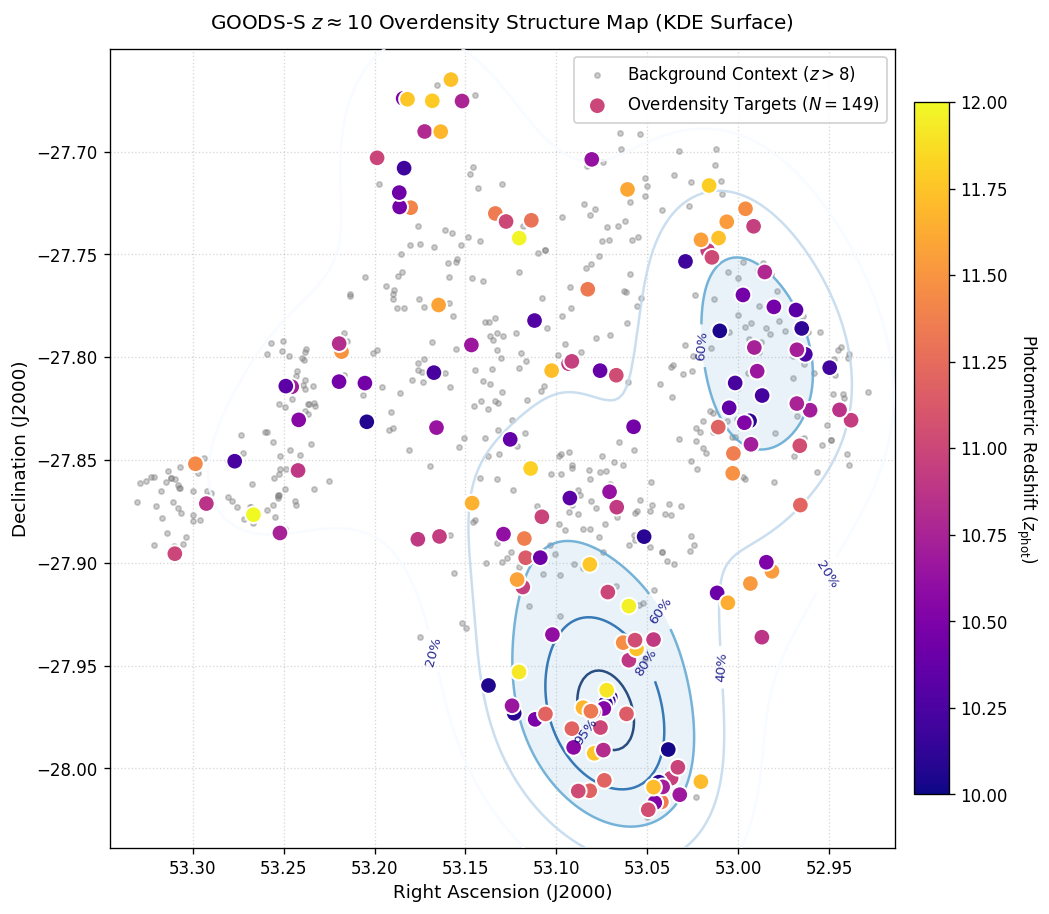

In [95]:
from astropy.table import Table

master_table_s = find_all('../inputs/OUTPUT_S/')
master_table_n = find_all('../inputs/OUTPUT_N/')

density_plot(master_table_s)

In [98]:
master_table_n[master_table_n['id'] == 1011069]

# plt.figure()

id,f_nircam_f070w,e_nircam_f070w,f_nircam_f090w,e_nircam_f090w,f_nircam_f115w,e_nircam_f115w,f_nircam_f150w,e_nircam_f150w,f_nircam_f162m,e_nircam_f162m,f_nircam_f182m,e_nircam_f182m,f_nircam_f200w,e_nircam_f200w,f_nircam_f210m,e_nircam_f210m,f_nircam_f277w,e_nircam_f277w,f_nircam_f300m,e_nircam_f300m,f_nircam_f335m,e_nircam_f335m,f_nircam_f356w,e_nircam_f356w,f_nircam_f410m,e_nircam_f410m,f_nircam_f430m,e_nircam_f430m,f_acs_f435w,e_acs_f435w,f_nircam_f444w,e_nircam_f444w,f_nircam_f460m,e_nircam_f460m,f_acs_f606w,e_acs_f606w,f_acs_f775w,e_acs_f775w,f_acs_f814w,e_acs_f814w,f_acs_f850lp,e_acs_f850lp,z_spec,RA,DEC,z_a
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32
1011069,-99.0,10000000000.0,-2.778234,1.890147,0.4439785,0.6408558,4.79671,0.9913096,7.830921,0.8764132,3.901886,2.097117,5.972203,0.4551288,7.221407,2.884728,5.414742,0.4024913,-99.0,10000000000.0,2.586643,2.113564,5.158847,0.7273293,2.239687,2.701437,-99.0,10000000000.0,-3.006986,1.835673,5.162124,0.7315648,-99.0,10000000000.0,1.327604,2.036129,1.993989,1.865369,1.212171,1.368663,6.516974,4.075503,-1.0,189.21353,62.260704,10.69853


In [42]:
def clean_via_catalog_match(cat1, cat2, max_separation=0.3):
    """
    Cross-matches two catalogs by RA/Dec and returns a clean subset of objects 
    that are mutually confirmed in both pipelines within a max_separation (arcseconds).
    """

    # 1. Convert both coordinate columns into Astropy SkyCoord objects
    my_coords = SkyCoord(ra=cat1['RA'], dec=cat1['DEC'], unit=(u.deg, u.deg))
    ref_coords = SkyCoord(ra=cat2['RA'], dec=cat2['DEC'], unit=(u.deg, u.deg))

    # 2. For every source in YOUR catalog, find the closest source in Hainline's catalog
    # idx: The index in ref_coords that is closest to each row of my_coords
    # sep2d: The actual angular distance on the sky between them
    idx, sep2d, _ = my_coords.match_to_catalog_sky(ref_coords)

    # 3. Create a boolean mask for matches that fall within our tolerance threshold
    # 0.3 arcseconds is standard for JWST NIRCam pixel dimensions (0.03"/pix or 0.06"/pix)
    matching_mask = sep2d < (max_separation * u.arcsec)
    
    n_matches = np.sum(matching_mask)
    print(f"Found {n_matches} confirmed sources within {max_separation}\".")

    return matching_mask

In [43]:
match_mask = clean_via_catalog_match(master_table_s, hainline_s)

Found 1659 confirmed sources within 0.3".


In [44]:
mask_files = sorted(glob.glob(f"../inputs/OUTPUT_S/*.npy"))

all_masks = np.array([])

for file in mask_files:
    loaded_mask = np.load(file)
    all_masks = np.append(all_masks, loaded_mask)

#### Check Missed Hainline Targets

In [45]:
og_present = 0
filt_present = 0
eazy_present = 0
z_pass = 0
chi2_pass = 0

highz_table = master_table_s[master_table_s['z_a'] > 8]
chi2_table = master_table_s[all_masks == 1]

highz_chi2 = chi2_table[chi2_table['z_a'] > 8]

for id in hainline_s['id']:
    if id in tab_final_s['ID']:
        og_present += 1
    if id in filtered_s['ID']:
        filt_present += 1
    if id in master_table_s['id']:
        eazy_present += 1
    if id in highz_table['id']:
        z_pass += 1
    if id in highz_chi2['id']:
        chi2_pass += 1

print(f'Initial Hainline GOODS-S sample: {len(hainline_s["id"])}')
print(f'Matches in original JADES data: {og_present}')
print(f'Passes filtration criterion: {filt_present}')
print(f'Found in EAZY save: {eazy_present}')

print(f'Photometric z > 8: {z_pass}')
print(f'Passed Chi2 criterion: {chi2_pass}')

Initial Hainline GOODS-S sample: 1597
Matches in original JADES data: 1597
Passes filtration criterion: 1597
Found in EAZY save: 1597
Photometric z > 8: 1459
Passed Chi2 criterion: 1379


In [46]:
f356w_detected = []
f356w_missed = []

err_detected = []
err_missed = []

for id in hainline_s['id']:
    flux_356 = hainline_s[hainline_s['id'] == id]['f_nircam_f356w'][0]
    err_356 = hainline_s[hainline_s['id'] == id]['e_nircam_f356w'][0]
    if flux_356 > -99:
        if id in highz_chi2['id']:
            f356w_detected.append(flux_356)
            err_detected.append(err_356)
        else:
            f356w_missed.append(flux_356)
            err_missed.append(err_356)
        
print(np.mean(f356w_detected))
print(np.mean(f356w_detected)/np.mean(err_detected))
print(np.mean(f356w_missed))
print(np.mean(f356w_missed)/np.mean(err_missed))

8.450498736066763
14.269861790733932
10.343054573394495
15.738603536481724


In [55]:
from astropy.table import vstack

def extract_non_recovered_targets(hainline_full_table, recovered_ids):
    """
    Filters a master table down to only the rows whose IDs 
    are missing from the recovered_ids collection.
    """
    # Convert recovered_ids to a set or numpy array for optimal lookup speed
    recovered_array = np.array(recovered_ids)
    
    # 1. Check which IDs ARE in the recovered list (yields a boolean array)
    is_recovered = np.isin(hainline_full_table['id'], recovered_array)
    
    # 2. Invert the boolean mask using the bitwise NOT operator (~)
    # True becomes False (gets thrown out), False becomes True (gets kept)
    missing_mask = ~is_recovered
    
    # 3. Slice the master table down to just the missed candidates
    missed_table = hainline_full_table[missing_mask]
    
    print(f"Total Hainline Targets: {len(hainline_full_table)}")
    print(f"Successfully Recovered: {len(hainline_full_table) - len(missed_table)}")
    print(f"Missed Targets remaining for diagnosis: {len(missed_table)}")
    
    return missed_table

print("Checking all conditionals...")
missed_all_conditions = extract_non_recovered_targets(hainline_s, highz_chi2['id'])
print("Checking for z condition...")
missed_z_condition = extract_non_recovered_targets(hainline_s, highz_table['id'])

Checking all conditionals...
Total Hainline Targets: 1597
Successfully Recovered: 1379
Missed Targets remaining for diagnosis: 218
Checking for z condition...
Total Hainline Targets: 1597
Successfully Recovered: 1459
Missed Targets remaining for diagnosis: 138


In [66]:
# Checking objects w/ f356w flux > 8 only
z_only = missed_z_condition[missed_z_condition['f_nircam_f356w'] > 8]
z_only.sort('f_nircam_f356w')

chi2_only = missed_all_conditions[(missed_all_conditions['z_a'] > 8) & (missed_all_conditions['f_nircam_f356w'] > 8)]

#### Visualize Missed Targets

ID 473560: Fitted photoz was 7.414020538330078


(-0.5, 879.5, 529.5, -0.5)

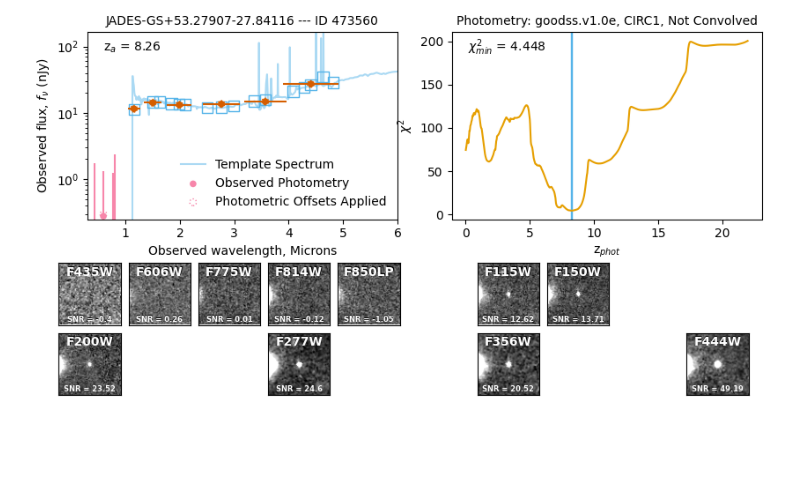

In [85]:
# Check targets that failed the z condition
import io
import requests

id = z_only['id'][26]	
print(f"ID {id}: Fitted photoz was {hainline_s[hainline_s['id'] == id]['z_a'][0]}")


base_url = "https://jades.idies.jhu.edu/goods-s/goodss_eazy_seds_v10e1/{}_EAZY_SED.png"
url = base_url.format(id)
response = requests.get(url, timeout=10)
img = Image.open(io.BytesIO(response.content))


# Create a single figure frame
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
ax.imshow(img)
ax.axis('off')

ID 471998: Fitted photoz was 8.239557266235352


(-0.5, 879.5, 529.5, -0.5)

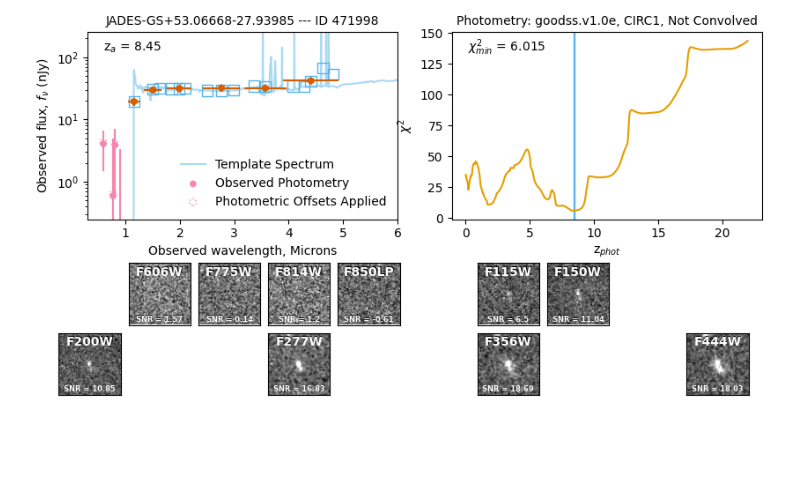

In [91]:
# Check targets that failed the chisquared condition
import io
import requests

id = chi2_only['id'][15]	
print(f"ID {id}: Fitted photoz was {hainline_s[hainline_s['id'] == id]['z_a'][0]}")


base_url = "https://jades.idies.jhu.edu/goods-s/goodss_eazy_seds_v10e1/{}_EAZY_SED.png"
url = base_url.format(id)
response = requests.get(url, timeout=10)
img = Image.open(io.BytesIO(response.content))


# Create a single figure frame
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
ax.imshow(img)
ax.axis('off')

#### Analyze Non-Hainline Detections

In [48]:
non_hainline = []

for id in highz_chi2['id']:
    if id not in hainline_s['id']:
        non_hainline.append(id)

len(non_hainline)

181

Starting optimized visual inspection loop.



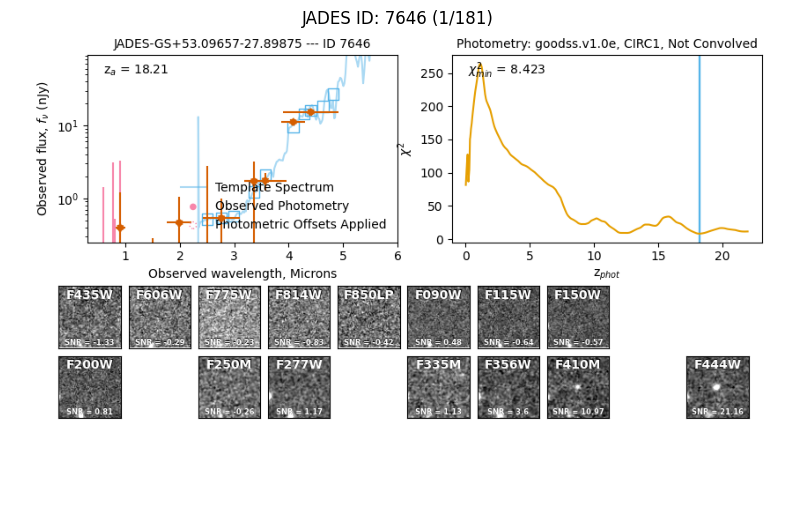

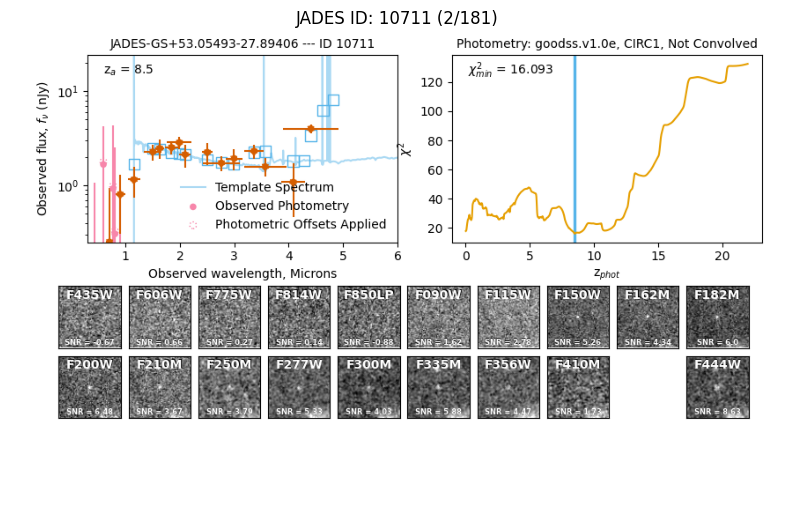

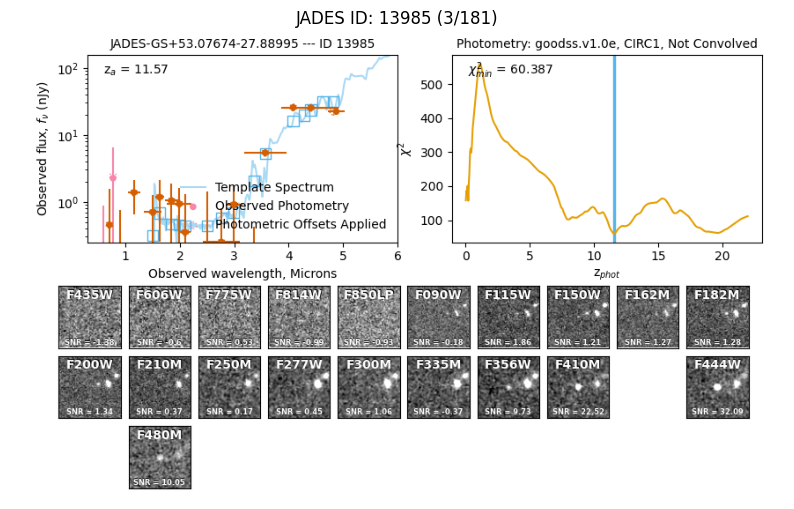

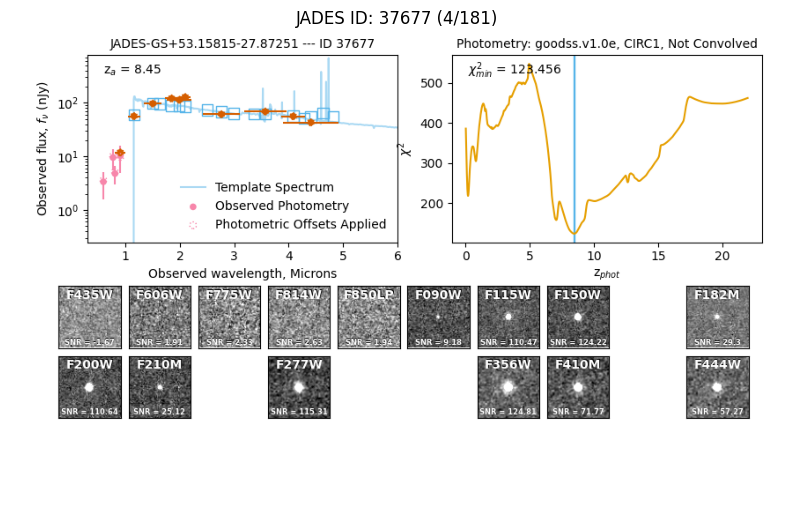

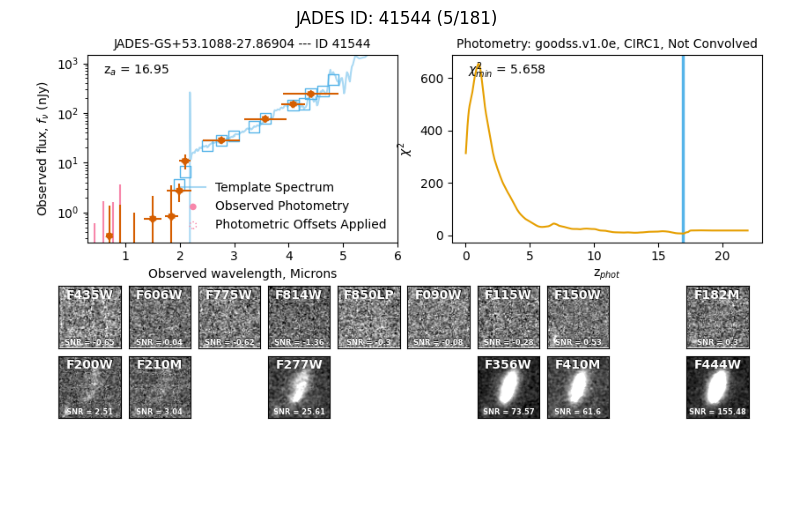

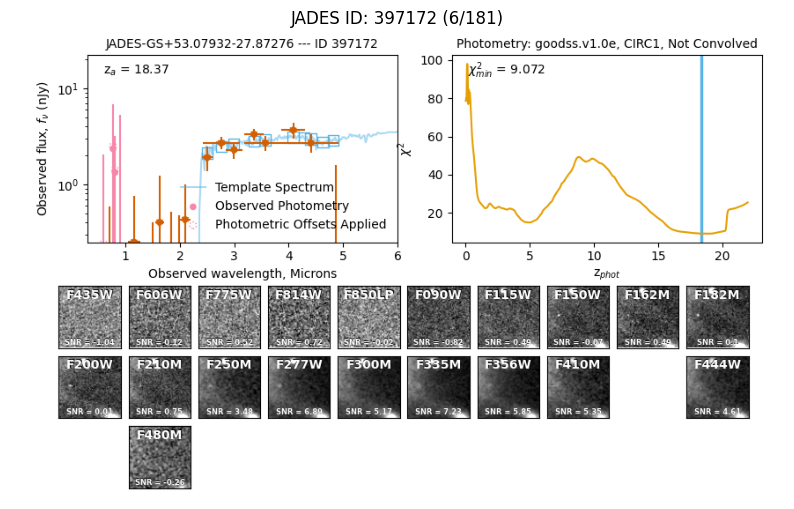

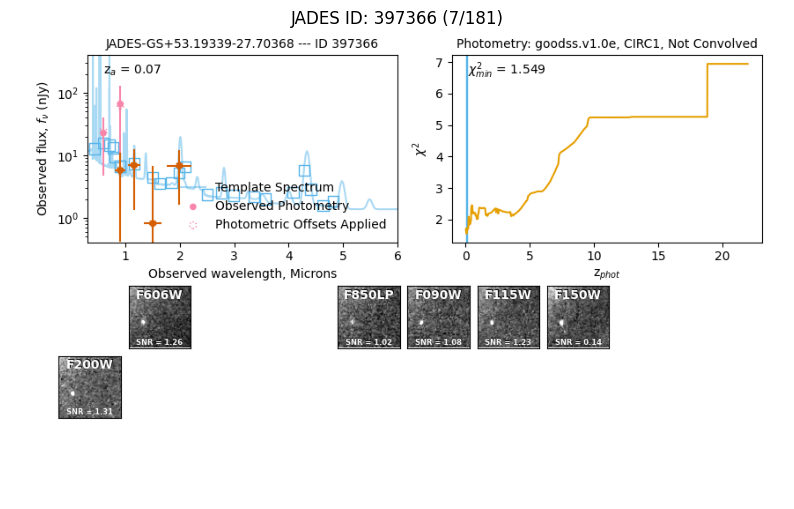

KeyboardInterrupt: Interrupted by user

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def inspect_jades_self_cleaning(jades_ids):
    """
    Displays one SED image at a time, immediately clearing it from memory
    after classification to prevent system lag.
    """
    base_url = "https://jades.idies.jhu.edu/goods-s/goodss_eazy_seds_v10e1/{}_EAZY_SED.png"
    results = {}
    
    # Enable interactive mode so plots update smoothly
    plt.ion() 
    
    print("Starting optimized visual inspection loop.\n")
    
    for i, obj_id in enumerate(jades_ids):
        url = base_url.format(obj_id)
        
        try:
            response = requests.get(url, timeout=10)
            if response.status_code != 200:
                continue
                
            img = Image.open(io.BytesIO(response.content))
            
            # Create a single figure frame
            fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
            ax.imshow(img)
            ax.axis('off')
            plt.title(f"JADES ID: {obj_id} ({i+1}/{len(jades_ids)})", fontsize=12)
            
            # Draw the plot onto the screen without locking the terminal execution
            plt.draw()
            plt.pause(0.1) 
            
            # Prompt for input while the image is open on screen
            flag = input(f"[{i+1}/{len(jades_ids)}] ID {obj_id} (g=galaxy / a=artifact / s=skip): ").strip().lower()
            
            # Log classification
            if flag in ['g', 'a']:
                results[obj_id] = 'galaxy' if flag == 'g' else 'artifact'
            else:
                results[obj_id] = 'skipped'
            
            # THE FIX: Explicitly drop the figure canvas entirely from memory before moving on
            plt.close(fig)
            
        except Exception as e:
            print(f"Error loading ID {obj_id}: {e}")
            plt.close('all')
            
    # Turn interactive mode back off
    plt.ioff()
    return results

visual_inspection_results = inspect_jades_self_cleaning(non_hainline)